# ОДНОРОДНЫЕ ФИЛЬТРЫ ИЛИ ФИЛЬТР СКОЛЬЗЯЩЕГО СРЕДНЕГО

Однородные фильтры превосходят все остальные виды цифровых фильтров при обработке информации, представленной во временной области. В то же время эти фильтры оказываются малоэффективны при обработке информации в частотной области. Следует помнить, что фильтра, лучшего, чем однородный, с точки зрения подавления шума, не существует.

Однородные фильтры часто называют фильтрами скользящего среднего:

$$
y[i] = \frac{1}{M} \sum_{j=0}^{M-1} x[i + j]
$$

**Примеры:**
$$
y[80] = \frac{x[80] + x[81] + x[82] + x[83] + x[84]}{5}
$$

$$
y[80] = \frac{x[78] + x[79] + x[80] + x[81] + x[82]}{5}
$$

При симметричном усреднении необходимо, чтобы $M$ б \
Почему нечетное! \
Окно фильтра в этом случае выглядит так: [... 78, 79, 80, 81, 82 ...]  \

Центр окна: Отсчёт x[80 \.

"Вес" (количество отсчётов) слева: 2 (x[78], x[7 \]).

"Вес" (количество отсчётов) справа: 2 (x[81], x \82]).

Окно является идеально симметричным относительно центрального  \
отсчёта.ыл нечётным числом.

Какие же преимущества характерны для рассмотренных выше модификаций однородных фильтров? Основных преимуществ — три.

*   **Во-первых,** модифицированные однородные фильтры позволяют достичь большего подавления в зоне непрозрачности, чем обычные однородные фильтры. (Зона непрозрачности фильтра — это диапазон частот, в котором фильтр значительно ослабляет сигнал).
*   **Во-вторых,** их импульсная характеристика на краях плавно сходится к нулю. Как вы помните, каждый отсчёт выходного сигнала определяется взвешенной суммой группы входных отсчётов. Поэтому сходимость к нулю импульсной характеристики означает, что отсчёты, близкие к центру такой группы, оказывают более сильное влияние на формирование выходного отсчёта.
*   **В-третьих,** переходные процессы у модифицированных фильтров оказываются более плавными и не имеют резких изгибов.

Последние два преимущества менее важны, хотя, надо заметить, существует ряд приложений, в которых они оказываются очень полезными.о нечётным числом.

In [59]:
# Импорт необходимых библиотек
import numpy as np  # для работы с массивами и математическими операциями
import matplotlib.pyplot as plt  # для построения графиков (хотя в коде используется Bokeh)
import math  # для математических функций

# библиотека на основе которой были сделаны графики
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/layouts.html
from bokeh.layouts import column  # для компоновки графиков в столбец
from bokeh.plotting import figure, show  # для создания и отображения графиков
from bokeh.io import output_notebook  # для вывода графиков в Jupyter Notebook

# Активируем вывод графиков в ноутбук
output_notebook()

# ОДНОРОДНЫЙ НЕРЕКУРСИВНЫЙ ФИЛЬТР (ФИЛЬТР СКОЛЬЗЯЩЕГО СРЕДНЕГО)
# Данная программа предназначена для обработки 5000 отсчётов
# входного сигнала однородным фильтром 101-го порядка.

# X – массив отсчётов входного сигнала
# Y – массив отсчётов выходного сигнала
def sliding_average_filter(X, coef):
    """
    Функция фильтра скользящего среднего
    
    Параметры:
    X - входной сигнал (список или массив)
    coef - количество точек для усреднения (порядок фильтра)
    
    Возвращает:
    Y - отфильтрованный сигнал
    """
    # Создаем выходной массив такой же длины как входной, заполненный нулями
    Y = [0.0] * len(X)
    
    # Цикл по числу отсчётов выходного сигнала
    # Обрабатываем от coef//2 до len(X) - coef//2 (исключаем краевые эффекты)
    range_from = coef // 2  # начальный индекс для обработки (половина окна)
    range_to = len(X) - coef // 2  # конечный индекс для обработки
    
    # Проходим по всем точкам, которые можно обработать полным окном
    for i in range(range_from, range_to):
        Y[i] = 0  # Предварительное обнуление текущего значения
        
        # Цикл для вычисления очередного отсчёта
        # Суммируем coef отсчетов вокруг текущей точки i
        for j in range(-(coef // 2), coef // 2 + coef % 2):
            Y[i] = Y[i] + X[i + j]  # Накопление суммы в окне
        
        # Завершение усреднения - операция деления на количество точек
        Y[i] = Y[i] / coef
    
    # Теперь массив Y содержит отфильтрованный сигнал
    # Полезные данные находятся в центре массива, края остаются нулевыми
    
    return Y

def load_data(len_x, Noise, F):
    """
    Функция генерации тестовых данных
    
    Параметры:
    len_x - длина генерируемого сигнала
    Noise - уровень шума
    F - частота полезного сигнала (в отсчетах)
    
    Возвращает:
    X - зашумленный сигнал
    clean - чистый сигнал (без шума)
    """
    # Заглушка - заполняем тестовыми данными
    # Например, синусоида с шумом
    import math
    import random
    
    X = [0.0] * len_x  # массив для зашумленного сигнала
    clean = [0.0] * len_x  # массив для чистого сигнала
    
    # Генерируем сигнал: синусоида + шум
    for i in range(len_x):
        # Чистый сигнал: синус частотой F
        signal = math.sin(2 * math.pi * F * i / len_x)
        # Шум: случайное значение от 0 до Noise
        noise = Noise * random.random()
        # Суммируем сигнал и шум
        X[i] = signal + noise
        # Сохраняем чистый сигнал для сравнения
        clean[i] = signal
        
    return X, clean 

# Основная программа
if __name__ == "__main__":
    # Параметры сигнала и фильтра
    signal_leng = 200  # длина сигнала в отсчетах
    noise_level = 3.9  # уровень шума
    F = 4  # частота полезного сигнала
    coef = 15  # порядок фильтра (количество точек для усреднения)
    
    # Генерируем тестовые данные
    X, clean = load_data(signal_leng, noise_level, F)
    
    # Применяем фильтр скользящего среднего
    output_signal = sliding_average_filter(X, coef)

# ----------------------------
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ----------------------------

# Создаем первый график - входной сигнал
p1 = figure(title="Входной сигнал", x_axis_label='Отсчеты', y_axis_label='Амплитуда')
# Нулевая линия для ориентира
p1.line(np.arange(len(X)), np.zeros(len(X)), line_color="black")
# Входной зашумленный сигнал
p1.line(np.arange(len(X)), X, legend_label="Зашумленный сигнал", line_color="blue")
# Чистый сигнал (для сравнения)
p1.line(np.arange(len(clean)), clean, legend_label="Чистый сигнал", line_color="red")
# Отображаем график
show(p1) 

# Создаем второй график - выходной сигнал после фильтрации
p2 = figure(title="Выходной сигнал после фильтра", x_axis_label='Отсчеты', y_axis_label='Амплитуда')
# Нулевая линия для ориентира
p2.line(np.arange(len(output_signal)), np.zeros(len(output_signal)), line_color="black")
# Отфильтрованный сигнал
p2.line(np.arange(len(output_signal)), output_signal, legend_label="Отфильтрованный сигнал", line_color="blue")
# Отображаем график
show(p2)

Loading BokehJS ...

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import math
# библиотека на основе которой были сделаны графики
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/layouts.html
from bokeh.layouts import column
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
# Активируем вывод графиков в ноутбук
output_notebook()

# ОДНОРОДНЫЙ НЕРЕКУРСИВНЫЙ ФИЛЬТР (ФИЛЬТР СКОЛЬЗЯЩЕГО СРЕДНЕГО)
# Данная программа предназначена для обработки 5000 отсчётов
# входного сигнала однородным фильтром 101-го порядка.

def sliding_average_filter():
    # X – массив отсчётов входного сигнала
    X = [0.0] * 5000
    # Y – массив отсчётов выходного сигнала
    Y = [0.0] * 5000
    
    def load_data():
        """
        Некоторая подпрограмма загрузки данных в X
        В реальной программе здесь должен быть код загрузки данных
        """
        # Заглушка - заполняем тестовыми данными
        # Например, синусоида с шумом
        import math
        import random
        for i in range(5000):
            # Сигнал: синус 5 Гц + шум
            signal = math.sin(2 * math.pi * 5 * i / 5000)
            noise = 0.5 * random.random()
            X[i] = signal + noise
    
    # Загрузка входных данных
    load_data()
    
    # Цикл по числу отсчётов выходного сигнала
    # Обрабатываем от 50 до 4949 (включительно)
    for i in range(50, 4950):
        Y[i] = 0  # Предварительное обнуление
        
        # Цикл для вычисления очередного отсчёта
        # Суммируем 101 отсчет: от i-50 до i+50
        for j in range(-50, 51):
            Y[i] = Y[i] + X[i + j]
        
        # Завершение усреднения - операция деления
        Y[i] = Y[i] / 101
    
    # Теперь массив Y содержит отфильтрованный сигнал
    # Полезные данные находятся в Y[50] до Y[4949]
    
    return X, Y

# Вызов функции фильтрации
if __name__ == "__main__":
    input_signal, output_signal = sliding_average_filter()
    
    # Пример вывода первых 100 отсчетов для проверки
    print("Первые 100 отсчетов входного и выходного сигналов:")
    print("i\tВход X[i]\tВыход Y[i]")
    for i in range(100):
        if i >= 50:  # Выходной сигнал доступен начиная с i=50
            print(f"{i}\t{input_signal[i]:.4f}\t\t{output_signal[i]:.4f}")
        else:
            print(f"{i}\t{input_signal[i]:.4f}\t\t---")
show(p) 


Loading BokehJS ...

Первые 100 отсчетов входного и выходного сигналов:
i	Вход X[i]	Выход Y[i]
0	0.2170		---
1	0.2212		---
2	0.3273		---
3	0.2629		---
4	0.0830		---
5	0.5084		---
6	0.3383		---
7	0.1026		---
8	0.4831		---
9	0.3543		---
10	0.5122		---
11	0.3294		---
12	0.4538		---
13	0.4966		---
14	0.4023		---
15	0.1222		---
16	0.1577		---
17	0.3319		---
18	0.2877		---
19	0.3523		---
20	0.1553		---
21	0.2392		---
22	0.5014		---
23	0.4649		---
24	0.5391		---
25	0.6016		---
26	0.6084		---
27	0.2594		---
28	0.1990		---
29	0.4934		---
30	0.2475		---
31	0.3637		---
32	0.4366		---
33	0.4642		---
34	0.5983		---
35	0.6044		---
36	0.5746		---
37	0.4736		---
38	0.3216		---
39	0.4581		---
40	0.6263		---
41	0.7090		---
42	0.6689		---
43	0.4268		---
44	0.7552		---
45	0.5566		---
46	0.7701		---
47	0.3347		---
48	0.5572		---
49	0.5133		---
50	0.7302		0.5454
51	0.3639		0.5518
52	0.3622		0.5585
53	0.3812		0.5647
54	0.8243		0.5696
55	0.6388		0.5775
56	0.5763		0.5810
57	0.7118		0.5875
58	0.5604		0.5940
59	0.4512		0.5958
60	0.7

In [2]:
# ОДНОРОДНЫЙ РЕКУРСИВНЫЙ ФИЛЬТР (ФИЛЬТР СКОЛЬЗЯЩЕГО СРЕДНЕГО)
# Данная программа предназначена для обработки 5000 отсчётов
# входного сигнала однородным фильтром 101-го порядка.
# Для устранения дрейфа накопление происходит с двойной точностью.

def recursive_moving_average_filter():
    # X – массив отсчётов входного сигнала
    X = [0.0] * 5000
    # Y – массив отсчётов выходного сигнала
    Y = [0.0] * 5000
    
    def load_data():
        """
        Некоторая подпрограмма загрузки данных в X
        В реальной программе здесь должен быть код загрузки данных
        """
        # Заглушка - заполняем тестовыми данными
        # Например, синусоида с шумом
        import math
        import random
        for i in range(5000):
            # Сигнал: синус 5 Гц + шум
            signal = math.sin(2 * math.pi * 5 * i / 5000)
            noise = 0.5 * random.random()
            X[i] = signal + noise
    
    # Загрузка входных данных
    load_data()
    
    # Использование переменной ACC с повышенной точностью (float в Python уже имеет двойную точность)
    ACC = 0.0
    
    # Вычисление Y[50] усреднением отсчётов X[0]…X[100]
    for i in range(0, 101):
        ACC = ACC + X[i]
    
    Y[50] = ACC / 101
    
    # Однородный рекурсивный фильтр (выражение 15.3)
    for i in range(51, 4950):
        # Обновление аккумулятора: добавляем новый отсчёт и вычитаем старый
        ACC = ACC + X[i + 50] - X[i - 51]
        Y[i] = ACC / 101
    
    # Теперь массив Y содержит отфильтрованный сигнал
    # Полезные данные находятся в Y[50] до Y[4949]
    
    return X, Y

# Вызов функции фильтрации
if __name__ == "__main__":
    input_signal, output_signal = recursive_moving_average_filter()
    
    # Пример вывода первых 100 отсчетов для проверки
    print("Первые 100 отсчетов входного и выходного сигналов:")
    print("i\tВход X[i]\tВыход Y[i]")
    for i in range(100):
        if i >= 50:  # Выходной сигнал доступен начиная с i=50
            print(f"{i}\t{input_signal[i]:.4f}\t\t{output_signal[i]:.4f}")
        else:
            print(f"{i}\t{input_signal[i]:.4f}\t\t---")

Первые 100 отсчетов входного и выходного сигналов:
i	Вход X[i]	Выход Y[i]
0	0.1459		---
1	0.1501		---
2	0.2281		---
3	0.2631		---
4	0.4658		---
5	0.2723		---
6	0.1055		---
7	0.0932		---
8	0.2431		---
9	0.2265		---
10	0.1716		---
11	0.5433		---
12	0.5640		---
13	0.4270		---
14	0.4232		---
15	0.4423		---
16	0.2740		---
17	0.4080		---
18	0.2227		---
19	0.4085		---
20	0.3405		---
21	0.3956		---
22	0.3817		---
23	0.5652		---
24	0.4716		---
25	0.2831		---
26	0.2715		---
27	0.1938		---
28	0.1805		---
29	0.2814		---
30	0.2518		---
31	0.6024		---
32	0.4569		---
33	0.5869		---
34	0.5476		---
35	0.4960		---
36	0.4769		---
37	0.5691		---
38	0.4032		---
39	0.5041		---
40	0.6818		---
41	0.3373		---
42	0.2956		---
43	0.7525		---
44	0.5796		---
45	0.3151		---
46	0.4864		---
47	0.3254		---
48	0.6997		---
49	0.7231		---
50	0.4718		0.5411
51	0.4200		0.5478
52	0.6021		0.5556
53	0.4033		0.5638
54	0.4764		0.5720
55	0.8342		0.5755
56	0.8159		0.5799
57	0.7039		0.5877
58	0.4365		0.5957
59	0.5091		0.6014
60	0.4

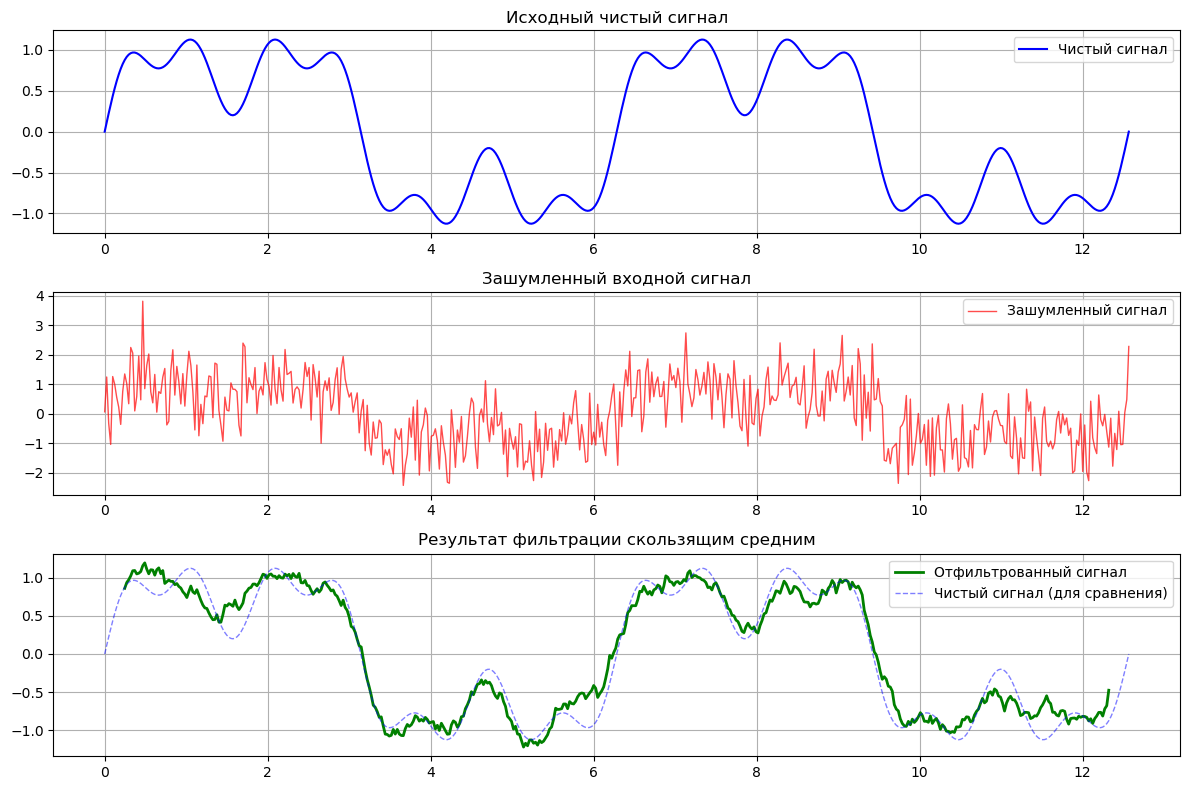

Обработано отсчётов: 512
Порядок фильтра: 21
Размер окна усреднения: 21 точек
Краевые эффекты: 10 точек с каждой стороны не обрабатываются


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ОДНОРОДНЫЙ НЕРЕКУРСИВНЫЙ ФИЛЬТР (ФИЛЬТР СКОЛЬЗЯЩЕГО СРЕДНЕГО)
# Данная программа предназначена для обработки 512 отсчётов
# входного сигнала однородным фильтром 21-го порядка (для 512 отсчётов)

def generate_noisy_signal(n_samples=512):
    """
    Генерация зашумленного тестового сигнала
    """
    t = np.linspace(0, 4*np.pi, n_samples)
    
    # Полезный сигнал - комбинация синусов разных частот
    signal = (np.sin(t) + 0.5 * np.sin(3*t) + 0.3 * np.sin(7*t))
    
    # Добавление шума
    noise = 0.8 * np.random.normal(0, 1, n_samples)
    noisy_signal = signal + noise
    
    return noisy_signal, signal, t


# Цикл 1: for i in range(HALF_ORDER, N - HALF_ORDER)
# i - это центральная точка окна фильтра
# Начало: HALF_ORDER = 10 - мы не можем взять окно с центром в точке 0-9, потому что не хватит точек слева
# Конец: N - HALF_ORDER = 512 - 10 = 502 - мы не можем взять окно с центром в точке 502-511, потому что не хватит точек справа
# Диапазон i: от 10 до 501 (включительно)
# Минимальный i = 10: окно охватывает точки X[0] до X[20]
# Максимальный i = 501: окно охватывает точки X[491] до X[511]
# Результат: обрабатываются точки Y[10] до Y[501] (всего 492 точки)

# Цикл 2: for j in range(-HALF_ORDER, HALF_ORDER + 1)
# Объяснение:
# j - это смещение относительно центральной точки i
# Начало: -HALF_ORDER = -10 - берем 10 точек слева от центра
# Конец: HALF_ORDER + 1 = 10 + 1 = 11 - берем 10 точек справа от центра + сам центр
# Диапазон j: от -10 до +10 (включительно)
# Всего 21 значение: [-10, -9, -8, ..., -1, 0, +1, ..., +8, +9, +10]


# Параметры
N = 512  # количество отсчётов
FILTER_ORDER = 21  # порядок фильтра (нечётное число)
HALF_ORDER = FILTER_ORDER // 2

# X – массив отсчётов входного сигнала
# Y – массив отсчётов выходного сигнала
X = [0] * N
Y = [0] * N

# Генерация тестового сигнала
X_noisy, X_clean, time = generate_noisy_signal(N)
X = X_noisy.tolist()  # преобразуем в список для совместимости
# Применение фильтра скользящего среднего
for i in range(HALF_ORDER, N - HALF_ORDER):
    Y[i] = 0  # Предварительное обнуление
    # Цикл для вычисления очередного отсчёта
    for j in range(-HALF_ORDER, HALF_ORDER + 1):
        Y[i] = Y[i] + X[i + j]
    Y[i] = Y[i] / FILTER_ORDER  # Завершение усреднения

# Визуализация результатов
plt.figure(figsize=(12, 8))

# Исходный чистый сигнал
plt.subplot(3, 1, 1)
plt.plot(time, X_clean, 'b-', linewidth=1.5, label='Чистый сигнал')
plt.title('Исходный чистый сигнал')
plt.grid(True)
plt.legend()

# Зашумленный сигнал
plt.subplot(3, 1, 2)
plt.plot(time, X, 'r-', linewidth=1, alpha=0.7, label='Зашумленный сигнал')
plt.title('Зашумленный входной сигнал')
plt.grid(True)
plt.legend()

# Отфильтрованный сигнал
plt.subplot(3, 1, 3)
plt.plot(time[HALF_ORDER:N-HALF_ORDER], Y[HALF_ORDER:N-HALF_ORDER], 
         'g-', linewidth=2, label='Отфильтрованный сигнал')
plt.plot(time, X_clean, 'b--', linewidth=1, alpha=0.5, label='Чистый сигнал (для сравнения)')
plt.title('Результат фильтрации скользящим средним')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Вывод статистики
print(f"Обработано отсчётов: {N}")
print(f"Порядок фильтра: {FILTER_ORDER}")
print(f"Размер окна усреднения: {FILTER_ORDER} точек")
print(f"Краевые эффекты: {HALF_ORDER} точек с каждой стороны не обрабатываются")

# ОДНОРОДНЫЕ ФИЛЬТРЫ

Однородные фильтры превосходят все остальные виды цифровых фильтров при обработке информации, представленной во временной области. В то же время эти фильтры оказываются малоэффективны при обработке информации в частотной области.

Однородные фильтры часто называют фильтрами скользящего среднего:

$$
y[i] = \frac{1}{M} \sum_{j=0}^{M-1} x[i + j]
$$

$$
y[80] = \frac{x[80] + x[81] + x[82] + x[83] + x[84]}{5}
$$

$$
y[80] = \frac{x[78] + x[79] + x[80] + x[81] + x[82]}{5}
$$

При симметричном усреднении необходимо, чтобы $ M $ было нечётным числом.

---

## Однородные рекурсивные фильтры

В частности, импульсная характеристика однородных фильтров имеет вид прямоугольного импульса, т. е. это фильтры с конечной импульсной характеристикой, или КИХ-фильтры, в то время как рекурсивные фильтры образуют класс БИХ-фильтров, а их импульсная характеристика имеет бесконечную длину и представляется набором синусоид и экспонент.

Пусть сигнал $ x[\cdot] $ поступает на вход однородного нерекурсивного фильтра седьмого порядка, а $ y[\cdot] $ — реакция этого фильтра. Тогда отсчёты $ y[50] $ и $ y[51] $ выражаются соотношениями:

$$
y[50] = x[47] + x[48] + x[49] + x[50] + x[51] + x[52] + x[53]
$$

и

$$
y[51] = x[48] + x[49] + x[50] + x[51] + x[52] + x[53] + x[54].
$$

Эти выражения во многом повторяют друг друга, поскольку отсчёты $ 48...53 $ используются для вычисления и $ y[50] $, и $ y[51] $. Если $ y[50] $ уже найден, то существует более эффективный способ вычислить $ y[51] $:

$$
y[51] = y[50] + x[54] - x[47].
$$

Если найдено значение $ y[50] $, то $ y[51] $ проще всего выразить через него. То же самое относится и к последующим отсчётам выходной последовательности. Если найден один отсчёт выходного сигнала $ y[\cdot] $, каждый последующий может быть найден в результате одной операции сложения и одной операции вычитания:

$$
y[i] = y[i-1] + x[i + p] - x[i - q], \tag{15.3}
$$

где

$$
p = \frac{M - 1}{2}, \quad q = p + 1.
$$

**Однородный рекурсивный фильтр.** Здесь $ x[\cdot] $ — входной сигнал, $ y[\cdot] $ — выходной сигнал, $ M $ — число (нечётное) усредняемых отсчётов. Перед началом использования этой формулы необходимо вычислить первый отсчёт выходной последовательности простым суммированием.

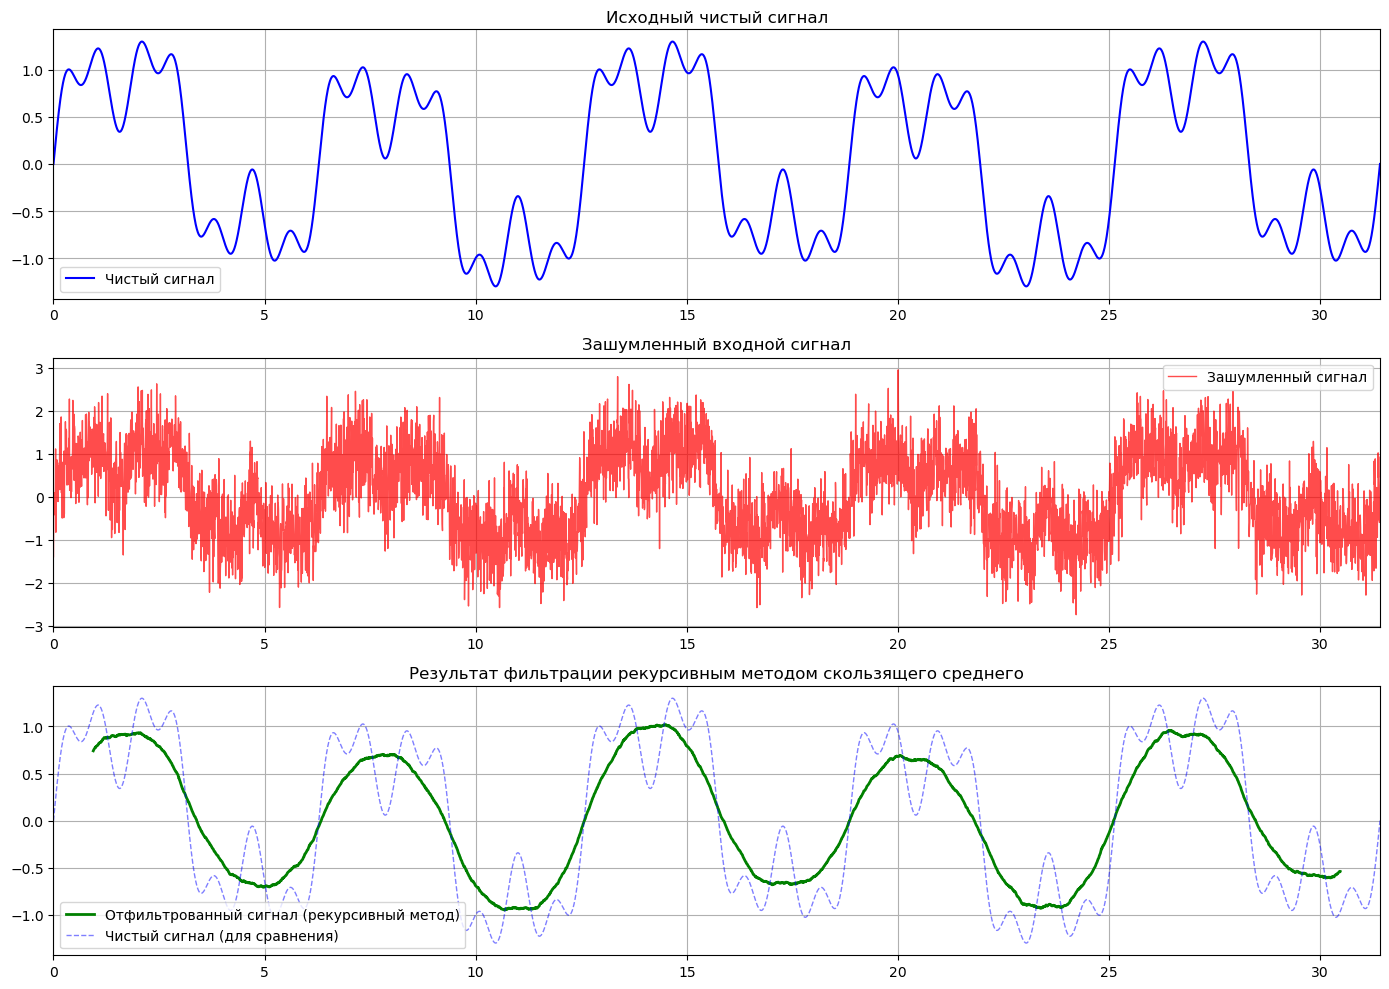

Сравнение методов фильтрации:
Обработано отсчётов: 5000
Порядок фильтра: 301
Размер окна усреднения: 301 точек
Краевые эффекты: 150 точек с каждой стороны не обрабатываются

Проверка корректности для точки 1000:
Рекурсивный метод: -0.060231
Нерекурсивный метод: -0.060231
Разница: 2.63e-15

Эффективность рекурсивного метода:
Количество операций сложения/вычитания на точку: 2
В нерекурсивном методе: 301 операций на точку
Ускорение: примерно в 150.5 раз


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def generate_test_signal(n_samples=5000):
    """
    Генерация тестового зашумленного сигнала
    """
    t = np.linspace(0, 10*np.pi, n_samples)
    
    # Полезный сигнал - комбинация синусов разных частот
    signal = (np.sin(t) + 0.5 * np.sin(3*t) + 0.3 * np.sin(7*t) + 
              0.2 * np.sin(0.5*t))
    
    # Добавление шума
    noise = 0.6 * np.random.normal(0, 1, n_samples)
    noisy_signal = signal + noise
    
    return noisy_signal, signal, t

# ОДНОРОДНЫЙ РЕКУРСИВНЫЙ ФИЛЬТР (ФИЛЬТР СКОЛЬЗЯЩЕГО СРЕДНЕГО)
# Данная программа предназначена для обработки 5000 отсчётов
# входного сигнала однородным фильтром 101-го порядка.
# Для устранения дрейфа накопление происходит с повышенной точностью.

# Параметры
N = 5000  # количество отсчётов
FILTER_ORDER = 301  # порядок фильтра
HALF_ORDER = FILTER_ORDER // 2  # = 50

# X – массив отсчётов входного сигнала
# Y – массив отсчётов выходного сигнала
X = np.zeros(N)
Y = np.zeros(N)

# Переменная для накопления с повышенной точностью
ACC = 0.0

# Генерация тестового сигнала
X_noisy, X_clean, time = generate_test_signal(N)
X = X_noisy  # используем зашумленный сигнал как вход

# Вычисление Y[50] усреднением отсчётов X[0]…X[100]
ACC = 0.0
for i in range(0, FILTER_ORDER):  # 0 до 100 включительно
    ACC += X[i]
Y[HALF_ORDER] = ACC / FILTER_ORDER  # Y[50]

# Однородный рекурсивный фильтр (выражение 15.3)
for i in range(HALF_ORDER + 1, N - HALF_ORDER):  # от 51 до 4949
    # Обновляем сумму: добавляем новый отсчёт и вычитаем старый
    ACC = ACC + X[i + HALF_ORDER] - X[i - HALF_ORDER - 1]
    Y[i] = ACC / FILTER_ORDER

# Визуализация результатов
plt.figure(figsize=(14, 10))

# Исходный чистый сигнал
plt.subplot(3, 1, 1)
plt.plot(time, X_clean, 'b-', linewidth=1.5, label='Чистый сигнал')
plt.title('Исходный чистый сигнал')
plt.grid(True)
plt.legend()
plt.xlim(0, time[-1])

# Зашумленный сигнал
plt.subplot(3, 1, 2)
plt.plot(time, X, 'r-', linewidth=1, alpha=0.7, label='Зашумленный сигнал')
plt.title('Зашумленный входной сигнал')
plt.grid(True)
plt.legend()
plt.xlim(0, time[-1])

# Отфильтрованный сигнал
plt.subplot(3, 1, 3)
plt.plot(time[HALF_ORDER:N-HALF_ORDER], Y[HALF_ORDER:N-HALF_ORDER], 
         'g-', linewidth=2, label='Отфильтрованный сигнал (рекурсивный метод)')
plt.plot(time, X_clean, 'b--', linewidth=1, alpha=0.5, label='Чистый сигнал (для сравнения)')
plt.title('Результат фильтрации рекурсивным методом скользящего среднего')
plt.grid(True)
plt.legend()
plt.xlim(0, time[-1])

plt.tight_layout()
plt.show()

# Сравнение с нерекурсивным методом для проверки
print("Сравнение методов фильтрации:")
print(f"Обработано отсчётов: {N}")
print(f"Порядок фильтра: {FILTER_ORDER}")
print(f"Размер окна усреднения: {FILTER_ORDER} точек")
print(f"Краевые эффекты: {HALF_ORDER} точек с каждой стороны не обрабатываются")

# Проверка: вычисление одного значения нерекурсивным методом для сравнения
test_index = 1000
non_recursive_sum = 0
for j in range(-HALF_ORDER, HALF_ORDER + 1):
    non_recursive_sum += X[test_index + j]
non_recursive_value = non_recursive_sum / FILTER_ORDER

print(f"\nПроверка корректности для точки {test_index}:")
print(f"Рекурсивный метод: {Y[test_index]:.6f}")
print(f"Нерекурсивный метод: {non_recursive_value:.6f}")
print(f"Разница: {abs(Y[test_index] - non_recursive_value):.2e}")

# Анализ эффективности
print(f"\nЭффективность рекурсивного метода:")
print(f"Количество операций сложения/вычитания на точку: 2")
print(f"В нерекурсивном методе: {FILTER_ORDER} операций на точку")
print(f"Ускорение: примерно в {FILTER_ORDER/2:.1f} раз")

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import math
# библиотека на основе которой были сделаны графики
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/layouts.html
from bokeh.layouts import column
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
# Активируем вывод графиков в ноутбук
output_notebook()

# ОДНОРОДНЫЙ НЕРЕКУРСИВНЫЙ ФИЛЬТР (ФИЛЬТР СКОЛЬЗЯЩЕГО СРЕДНЕГО)
# Данная программа предназначена для обработки 5000 отсчётов
# входного сигнала однородным фильтром 101-го порядка.

# X – массив отсчётов входного сигнала
# Y – массив отсчётов выходного сигнала
def sliding_average_filter(X,coef):
    Y = [0.0] * len(X)
    
    # Цикл по числу отсчётов выходного сигнала
    # Обрабатываем от 50 до 4949 (включительно)
    range_from = coef//2
    range_to = len(X) - coef
    
    for i in range(range_from, range_to):
        Y[i] = 0  # Предварительное обнуление
        
        # Цикл для вычисления очередного отсчёта
        # Суммируем 101 отсчет: от i-50 до i+50
        for j in range(-range_from, range_from + coef%2):
            Y[i] = Y[i] + X[i + j]
        
        # Завершение усреднения - операция деления
        Y[i] = Y[i] / coef
    
    # Теперь массив Y содержит отфильтрованный сигнал
    # Полезные данные находятся в Y[50] до Y[4949]
    
    return Y

def load_data(len_x, Noise,F):
    """
    Некоторая подпрограмма загрузки данных в X
    В реальной программе здесь должен быть код загрузки данных
    """
    # Заглушка - заполняем тестовыми данными
    # Например, синусоида с шумом
    import math
    import random
    
    X = [0.0] * len_x
    clean = [0.0] * len_x
    for i in range(len_x):
        # Сигнал: синус F Гц + шум
        signal = math.sin(2 * math.pi * F * i / len_x)
        noise = Noise * random.random()
        X[i] = signal + noise
        clean[i] = signal
    return X, clean 
    
# Вызов функции фильтрации
if __name__ == "__main__":
    signal_leng = 200
    noise_level = 3.9
    F = 4
    coef = 15
    X,clean = load_data(signal_leng,noise_level,F)
    output_signal = sliding_average_filter(X,coef)

# ----------------------------
# ВИЗУАЛИЗАЦИЯ
# ----------------------------

p1 = figure(title="входной сигнал", x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p1.line(np.arange(len(X)), np.zeros(len(X)), line_color="black")
# p1.scatter(np.arange(len(X)), X, size=7, marker="circle", legend_label="sum_wave", line_color="blue", fill_alpha=0.3)
p1.line(np.arange(len(X)), X, legend_label="X", line_color="blue")
p1.line(np.arange(len(clean)), clean, legend_label="clean", line_color="red")
show(p1) 

p2 = figure(title="выходной сигнал", x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p2.line(np.arange(len(output_signal)), np.zeros(len(output_signal)), line_color="black")
# p2.scatter(np.arange(len(X)), X, size=7, marker="circle", legend_label="sum_wave", line_color="blue", fill_alpha=0.3)
p2.line(np.arange(len(output_signal)), output_signal, legend_label="sum_wave", line_color="blue")
show(p2) 


Loading BokehJS ...